In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
data = np.random.randn(10_000)

(array([  32.,  185.,  736., 1784., 2696., 2534., 1433.,  486.,   98.,
          16.]),
 array([-3.42639357, -2.71681862, -2.00724366, -1.29766871, -0.58809375,
         0.1214812 ,  0.83105616,  1.54063111,  2.25020607,  2.95978102,
         3.66935598]),
 <BarContainer object of 10 artists>)

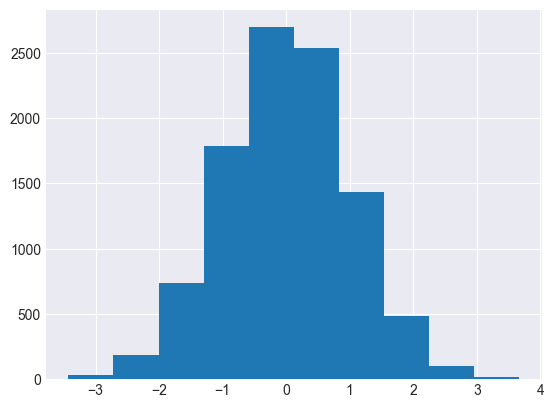

In [4]:
plt.hist(data)

(array([  1.,   6.,   4.,   9.,  12.,  14.,  24.,  40.,  49.,  58.,  73.,
        110., 161., 173., 219., 255., 304., 370., 408., 447., 533., 514.,
        548., 520., 581., 580., 545., 531., 457., 421., 400., 330., 281.,
        246., 176., 151., 119.,  97.,  68.,  51.,  39.,  21.,  25.,   9.,
          4.,   6.,   4.,   1.,   1.,   4.]),
 array([-3.42639357, -3.28447858, -3.14256359, -3.0006486 , -2.85873361,
        -2.71681862, -2.57490363, -2.43298864, -2.29107365, -2.14915866,
        -2.00724366, -1.86532867, -1.72341368, -1.58149869, -1.4395837 ,
        -1.29766871, -1.15575372, -1.01383873, -0.87192374, -0.73000875,
        -0.58809375, -0.44617876, -0.30426377, -0.16234878, -0.02043379,
         0.1214812 ,  0.26339619,  0.40531118,  0.54722617,  0.68914116,
         0.83105616,  0.97297115,  1.11488614,  1.25680113,  1.39871612,
         1.54063111,  1.6825461 ,  1.82446109,  1.96637608,  2.10829108,
         2.25020607,  2.39212106,  2.53403605,  2.67595104,  2.81786603,
 

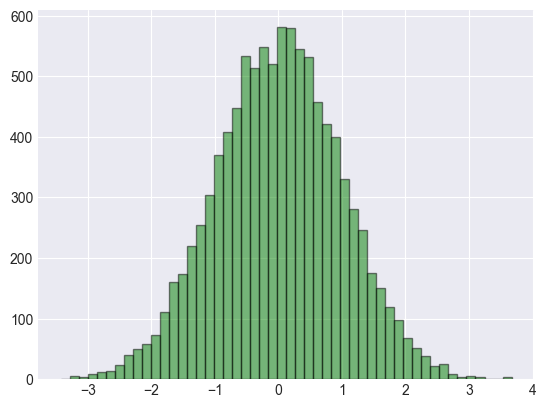

In [5]:
plt.hist(data, bins=50, alpha=0.5, color='g', edgecolor='black')

In [6]:
def min_max_normalize(arr):
    arr = np.asarray(arr, dtype=float)
    arr_min = arr.min()
    arr_max = arr.max()
    return (arr - arr_min) / (arr_max - arr_min)

Text(0, 0.5, 'Frequency')

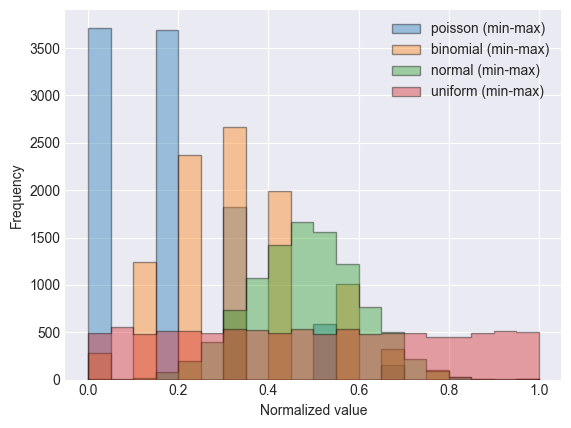

In [7]:
data1 = np.random.poisson(lam=1, size=10_000)
data2 = np.random.binomial(n=10, p=0.3, size=10_000)
data3 = np.random.normal(loc=0, scale=1, size=10_000)
data4 = np.random.uniform(low=-3, high=3, size=10_000)

data1_mm = min_max_normalize(data1)
data2_mm = min_max_normalize(data2)
data3_mm = min_max_normalize(data3)
data4_mm = min_max_normalize(data4)

kwargs = dict(alpha=0.4, bins=20, edgecolor='black', histtype='stepfilled')

plt.hist(data1_mm, **kwargs, label='poisson (min-max)')
plt.hist(data2_mm, **kwargs, label='binomial (min-max)')
plt.hist(data3_mm, **kwargs, label='normal (min-max)')
plt.hist(data4_mm, **kwargs, label='uniform (min-max)')
plt.legend()
plt.xlabel('Normalized value')
plt.ylabel('Frequency')

In [8]:
count, _ = np.histogram(data1_mm, bins=20)
count

array([3717,    0,    0, 3688,    0,    0, 1827,    0,    0,    0,  586,
          0,    0,  152,    0,    0,   25,    0,    0,    5])

# 2D data histograms and binnings
## plt.hist2d for td histogram

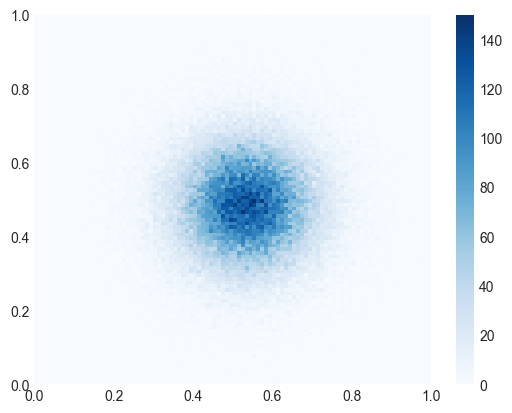

In [9]:
x = min_max_normalize(np.random.randn(100_000))
y = min_max_normalize(np.random.randn(100_000))
plt.hist2d(x, y, bins=100, cmap='Blues')
plt.colorbar()

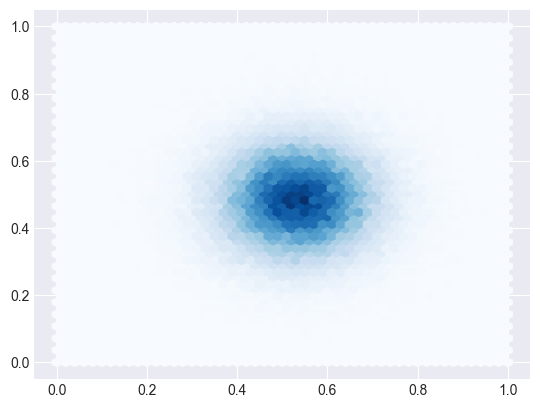

In [10]:
plt.hexbin(x, y, gridsize=50, cmap='Blues')

# KDE

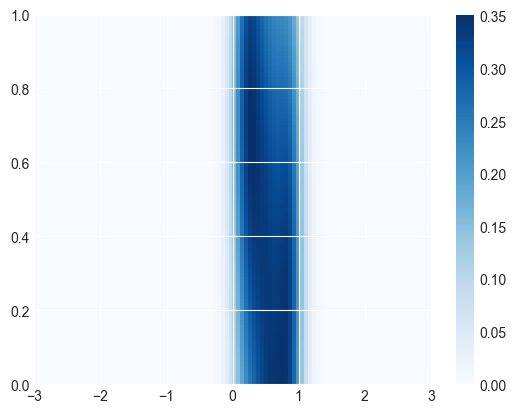

In [21]:
from scipy.stats import gaussian_kde

x = np.random.rand(100)
y = np.random.randn(100)

x = np.vstack([x, y])
kde = gaussian_kde(x)

x_points = np.linspace(-3, 3, 100)
y_points = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x_points, y_points)
Z = kde.evaluate(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
plt.imshow(Z, origin='lower', aspect='auto', extent=[-3, 3, 0, 1], cmap='Blues')
plt.colorbar()

note other functions in scipy and other libaries for different density estimations.